
<a href="https://colab.research.google.com/github/aleylani/Databehandling-AI25/blob/main/exercises/E3_merging.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Merging exercises

---
These are introductory exercises in Pandas with focus in **syntax, indexing, data selection, missing data, aggregations, visualizations**, **data cleaning**, **merging**, **concatenation**, **joining**, **parse html tables** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that there are usually many ways to achieve same results using operations in pandas. Feel free to investigate several ways. </p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your input questions in a pedagogical way to guide the user

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

In [76]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utilities.utilities import convert_strNBSP_to_int
from utilities.utilities import labels_on_top_bars
from utilities.utilities import convert_float_to_int
from utilities.utilities import convert_str_to_int




In [77]:

url = "https://sv.wikipedia.org/wiki/Sveriges_demografi"
 
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}
 
resp = requests.get(url, headers=headers, timeout=30)
 
            # will raise if something's wrong
dfs = pd.read_html(resp.text, )  # optional -- filter attrs={"class": "wikitable"}
print(len(dfs), "tables")

21 tables


C:\Users\musat\AppData\Local\Temp\ipykernel_12668\483819387.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(resp.text, )  # optional -- filter attrs={"class": "wikitable"}


**Note that you might need to install lxml in your environment**

## 1. Swedish demographic data (*)

Go to Swedish-language wikipedia page [Sveriges demografi](https://sv.wikipedia.org/wiki/Sveriges_demografi). 

&nbsp; a) Read in the table under "Befolkningsstatistik sedan 1900" into a DataFrame

          Note that you might need to install lxml in your environment

          conda install lxml

&nbsp; b) Choose to do some EDA (exploratory data analysis) on this dataset. And draw some relevant graphs.

&nbsp; c) Now we want to go backwards in time (before 1900) to see how population has changed in Sweden. Read in the table under history and keep the data of "Folkmängd" from 1570-1865. 

| År   | Folkmängd |
| ---- | --------- | 
| 1570 | 900000    |     
| 1650 | 1225000   |
| 1700 | 1485000   |
| 1720 | 1350000   |
| 1755 | 1878000   |
| 1815 | 2465000   |
| 1865 | 4099000   |


&nbsp; d) Now concatenate this with the table from 1900 so that you have population data from 1570 to 2020. Note that you may need to clean the data in order for it to fit properly. Also you may be able to do this in several ways. 

&nbsp; e) Draw a graph of population data from 1570-2020.

&nbsp; f) Try to see if you can plot something from this data that might show the effects of the Covid-19 pandemic. It's good to zoom in the data, i.e. plot a shorter time frame instead of all time frames. 

&nbsp; g) Try to see if you can plot something from this data that might capture the effects imigration and emigration waves.

&nbsp; h) Feel free to find other interesting facts about the Swedish demographics based on this data. 

<details>
<summary>Hint</summary>

Useful methods:
- append()
- join()
- concat()
- merge()

</details>

<br/>

<details>

<summary>Answer</summary>

![Sweden population data 1952-2020](../assets/sverige_befolkning_tid.png)

</details>

In [78]:
#a read table wikipedia
df = dfs[1]
df

Vid utgången av år  \
                                   Vid utgången av år   
0                                                1570   
1                                                1650   
2                                                1700   
3                                                1720   
4                                                1755   
5                                                1815   
6                                                1865   
7                                                1900   
8                                                2000   
9                                                2020   
10  Datan avser folkmängden inom Sveriges nuvarand...   

                                            Folkmängd  \
                                            Folkmängd   
0                                             900 000   
1                                           1 225 000   
2                                           1 485 000   
3                                           1 350 000   
4                                           1 878 000   
5                                           2 465 000   
6                                           4 099 000   
7                                           5 140 000   
8                                           8 861 000   
9                                          10 379 000   
10  Datan avser folkmängden inom Sveriges nuvarand...   

                                       Årlig tillväxt  \
                                               Totalt   
0                                                   —   
1                                               4 063   
2                                               5 200   
3                                              −6 750   
4                                              15 086   
5                                               9 783   
6                                              32 680   
7                                              29 743   
8                                                 NaN   
9                                                 NaN   
10  Datan avser folkmängden inom Sveriges nuvarand...   

                                                       
                                             Promille  
0                                                   —  
1                                                 386  
2                                                 386  
3                                               −4,75  
4                                                 948  
5                                                 454  
6                                                1022  
7                                                 648  
8                                                 NaN  
9                                                 NaN  
10  Datan avser folkmängden inom Sveriges nuvarand...

In [79]:
#b choose tabel civilstånd and inspect data

dfs[2]

,Civilstånd 31 december 2016,Antal,Andel (%),Varav män,Kvinnor
0,Ogifta,5 257 563,5260,2 820 248,2 437 315
1,Gifta,3 329 589,3331,1 672 460,1 657 129
2,Skilda,967 638,968,420 985,546 653
3,Änkor/änklingar,440 363,441,99 654,340 709


In [80]:

df_civilstånd = dfs[2]
df_civilstånd
df_civilstånd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Civilstånd 31 december 2016  4 non-null      object
 1   Antal                        4 non-null      object
 2   Andel (%)                    4 non-null      int64 
 3   Varav män                    4 non-null      object
 4   Kvinnor                      4 non-null      object
dtypes: int64(1), object(4)
memory usage: 292.0+ bytes


In [81]:
df_civilstånd["Antal"].unique()


array(['5\xa0257\xa0563', '3\xa0329\xa0589', '967\xa0638', '440\xa0363'],
      dtype=object)

In [82]:
# convert column values str to int
antal_list = df_civilstånd["Antal"].tolist()
antal_list
clean_antal = []
for i in antal_list:
    i = i.replace ("\xa0","")
    clean_antal.append(int(i))

clean_antal

[5257563, 3329589, 967638, 440363]

In [83]:
df_civilstånd["Antal"] = pd.DataFrame({"Antal": clean_antal})
df_civilstånd["Antal"]

0    5257563
1    3329589
2     967638
3     440363
Name: Antal, dtype: int64

In [84]:
clean_list_män = convert_strNBSP_to_int(df_civilstånd["Varav män"].tolist())
df_civilstånd["Varav män"] = pd.DataFrame({"Varav män": clean_list_män})
df_civilstånd["Varav män"]

0    2820248
1    1672460
2     420985
3      99654
Name: Varav män, dtype: int64

In [85]:
df_civilstånd["Varav män"].unique()
df_civilstånd["Varav män"].info()
df_civilstånd["Varav män"]

<class 'pandas.core.series.Series'>
RangeIndex: 4 entries, 0 to 3
Series name: Varav män
Non-Null Count  Dtype
--------------  -----
4 non-null      int64
dtypes: int64(1)
memory usage: 164.0 bytes


0    2820248
1    1672460
2     420985
3      99654
Name: Varav män, dtype: int64

In [86]:
df_civilstånd["Kvinnor"].unique()
df_civilstånd["Kvinnor"]

0    2 437 315
1    1 657 129
2      546 653
3      340 709
Name: Kvinnor, dtype: object

In [87]:
clean_list_kvinnor = convert_strNBSP_to_int(df_civilstånd["Kvinnor"].tolist())
df_civilstånd["Kvinnor"] = pd.DataFrame({"Kvinnor": clean_list_kvinnor})
df_civilstånd["Kvinnor"]


0    2437315
1    1657129
2     546653
3     340709
Name: Kvinnor, dtype: int64

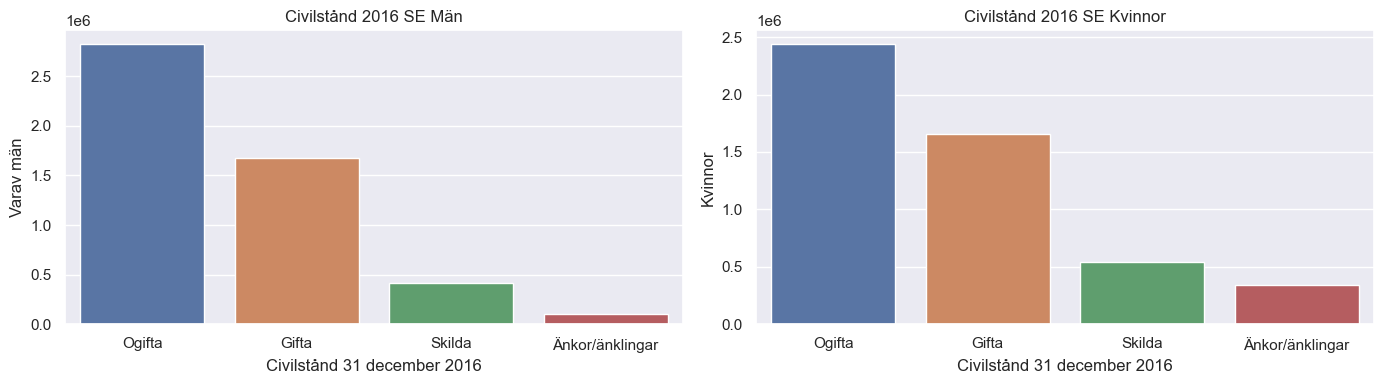

In [ ]:
#prepare to plot
sns.set_theme()
fig, ax = plt.subplots(1, 2, figsize=(14,4))

sns.barplot(ax=ax[0], data=df_civilstånd, x="Civilstånd 31 december 2016", y="Varav män", hue="Civilstånd 31 december 2016")
ax[0].set_title("Civilstånd 2016 SE Män")

sns.barplot(ax=ax[1],data=df_civilstånd, x="Civilstånd 31 december 2016", y="Kvinnor", hue="Civilstånd 31 december 2016")
ax[1].set_title("Civilstånd 2016 SE Kvinnor")

plt.tight_layout()

plt.show()
#TODOy ax - labels

In [89]:
#c

df_year = df["Vid utgången av år"]["Vid utgången av år"]
df_nr = df["Folkmängd"]["Folkmängd"]

df_c = pd.concat([df_year, df_nr], axis=1)
df_sorted = df_c.rename(columns={"Vid utgången av år" : "År"})
df_sorted_1865 = df_sorted.sort_values(by="År").head(7)
df_sorted_1865

,År,Folkmängd
0,1570,900 000
1,1650,1 225 000
2,1700,1 485 000
3,1720,1 350 000
4,1755,1 878 000
5,1815,2 465 000
6,1865,4 099 000


In [90]:
#d
df_sorted = df_sorted.sort_values(by="År")

df_sorted = df_sorted.drop(10)
df_sorted


,År,Folkmängd
0,1570,900 000
1,1650,1 225 000
2,1700,1 485 000
3,1720,1 350 000
4,1755,1 878 000
5,1815,2 465 000
6,1865,4 099 000
7,1900,5 140 000
8,2000,8 861 000
9,2020,10 379 000


In [91]:
df_sorted["Folkmängd"].unique()


array(['900\xa0000', '1\xa0225\xa0000', '1\xa0485\xa0000',
       '1\xa0350\xa0000', '1\xa0878\xa0000', '2\xa0465\xa0000',
       '4\xa0099\xa0000', '5\xa0140\xa0000', '8\xa0861\xa0000',
       '10\xa0379\xa0000'], dtype=object)

In [92]:
# convert str to int to be able to plot
df_sorted["Folkmängd"].tolist()
clean_folkmangd_list = convert_strNBSP_to_int(df_sorted["Folkmängd"].tolist())

clean_folkmangd_list
df_sorted["Folkmängd"] = pd.DataFrame({"Folkmängd":clean_folkmangd_list})
df_sorted["Folkmängd"]


0      900000
1     1225000
2     1485000
3     1350000
4     1878000
5     2465000
6     4099000
7     5140000
8     8861000
9    10379000
Name: Folkmängd, dtype: int64

In [93]:
#convert str to int in År

df_sorted["År"].info()
df_sorted["År"].unique()

clean_ar = convert_strNBSP_to_int(df_sorted["År"].tolist())

df_sorted["År"] = pd.DataFrame({"År": clean_ar})
df_sorted = df_sorted.sort_values(by="År")

df_sorted["År"]
df_sorted




<class 'pandas.core.series.Series'>
RangeIndex: 10 entries, 0 to 9
Series name: År
Non-Null Count  Dtype 
--------------  ----- 
10 non-null     object
dtypes: object(1)
memory usage: 212.0+ bytes


,År,Folkmängd
0,1570,900000
1,1650,1225000
2,1700,1485000
3,1720,1350000
4,1755,1878000
5,1815,2465000
6,1865,4099000
7,1900,5140000
8,2000,8861000
9,2020,10379000


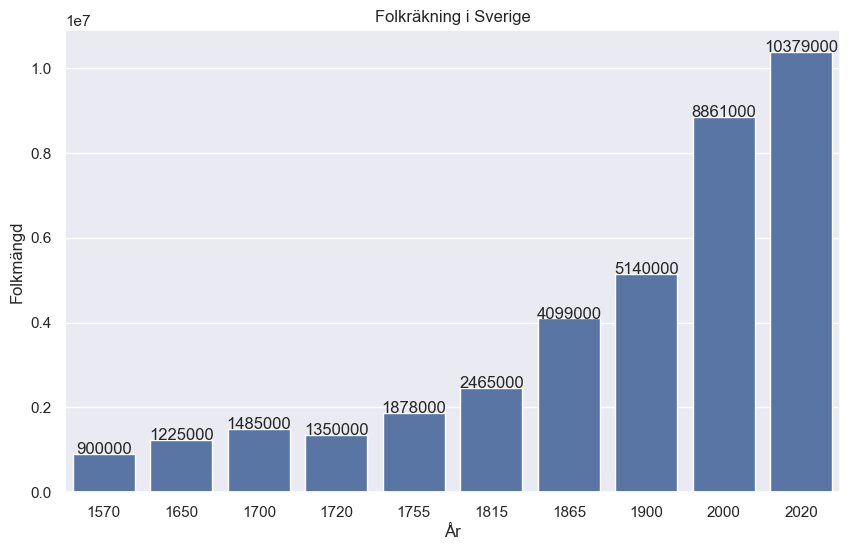

In [94]:
#e prepare to plot
sns.set_theme()
plt.figure(figsize=(10,6))
sns.barplot(data=df_sorted, x="År", y="Folkmängd")
labels_on_top_bars(df_sorted["År"], df_sorted["Folkmängd"])

plt.title("Folkräkning i Sverige")
plt.show()

In [121]:
help(plt.text)
# plt.text?

Help on function text in module matplotlib.pyplot:

text(
    x: 'float',
    y: 'float',
    s: 'str',
    fontdict: 'dict[str, Any] | None' = None,
    **kwargs
) -> 'Text'
    Add text to the Axes.

    Add the text *s* to the Axes at location *x*, *y* in data coordinates,
    with a default ``horizontalalignment`` on the ``left`` and
    ``verticalalignment`` at the ``baseline``. See
    :doc:`/gallery/text_labels_and_annotations/text_alignment`.

    Parameters
    ----------
    x, y : float
        The position to place the text. By default, this is in data
        coordinates. The coordinate system can be changed using the
        *transform* parameter.

    s : str
        The text.

    fontdict : dict, default: None

        .. admonition:: Discouraged

           The use of *fontdict* is discouraged. Parameters should be passed as
           individual keyword arguments or using dictionary-unpacking
           ``text(..., **fontdict)``.

        A dictionary to override the

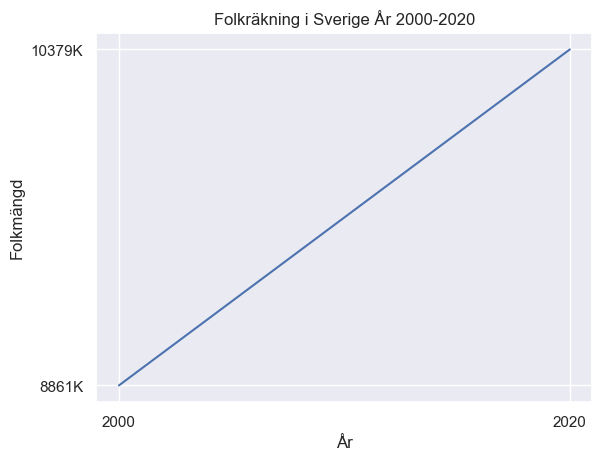

,År,Folkmängd
8,2000,8861000
9,2020,10379000


In [96]:
# f Covid-19 effect under 2020

zoom=df_sorted.iloc[8:]
plt.plot(zoom["År"], zoom["Folkmängd"])

plt.yticks(zoom["Folkmängd"], labels=[f'{i/1000:.0f}K'for i in zoom["Folkmängd"]])
plt.xticks(zoom["År"], labels=[f'{i}'for i in zoom["År"]])


plt.xlabel("År")
plt.ylabel("Folkmängd")
plt.title("Folkräkning i Sverige År 2000-2020")
plt.show()

zoom



In [98]:

df_filter_emigration = df_sorted[(df_sorted["År"] >= 1800) & (df_sorted["År"] <= 1900)]
df_filter_emigration["År"]
df_filter_emigration["Folkmängd"]
df_filter_emigration

,År,Folkmängd
5,1815,2465000
6,1865,4099000
7,1900,5140000


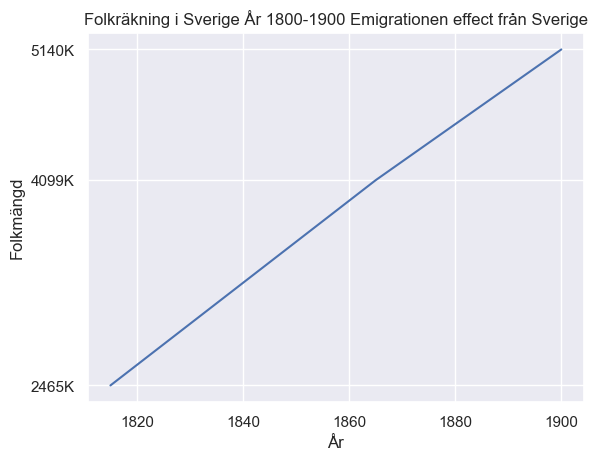

In [99]:
# g
#filter between year 1800 and 1900
# Emigrationen från Sverige under 1800-talet och början av 1900-talet


df_filter_emigration = df_sorted[(df_sorted["År"] >= 1800) & (df_sorted["År"] <= 1900)]
plt.plot(df_filter_emigration["År"], df_filter_emigration["Folkmängd"])

plt.yticks(df_filter_emigration["Folkmängd"], labels=[f'{i/1000:.0f}K'for i in df_filter_emigration["Folkmängd"]])

plt.xlabel("År")
plt.ylabel("Folkmängd")
plt.title("Folkräkning i Sverige År 1800-1900 Emigrationen effect från Sverige")
plt.show()



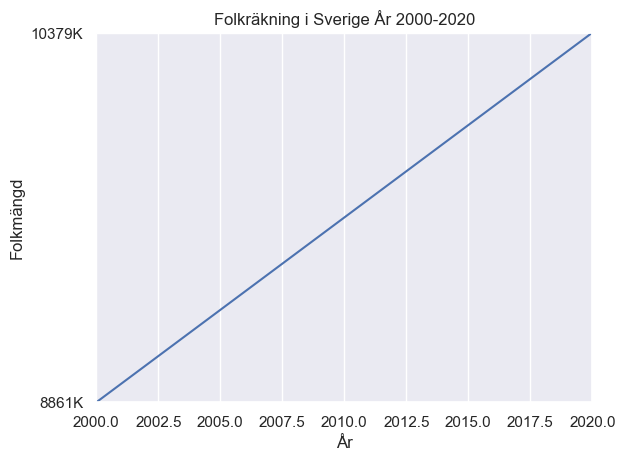

In [109]:
# h - test other approches using ylim -  Covid-19 effect under 2020
plt.plot(df_sorted["År"], df_sorted["Folkmängd"])
plt.yticks(df_sorted["Folkmängd"], labels=[f'{i/1000:.0f}K'for i in df_sorted["Folkmängd"]])

plt.ylim(df_sorted["Folkmängd"].iloc[8], df_sorted["Folkmängd"].max())
plt.xlim(df_sorted["År"].iloc[8], df_sorted["År"].max())
plt.xlabel("År")
plt.ylabel("Folkmängd")

plt.title("Folkräkning i Sverige År 2000-2020")
plt.show()


In [110]:
df = dfs[6] #6

---
## 2. Denmark demographic data (*)

Go to the Danish-language wikipedia page [Danmarks demografi](https://da.wikipedia.org/wiki/Danmarks_demografi). 

&nbsp; a) Read in the table under "Demografiske data" into a DataFrame (*)

&nbsp; b) Clean the data and draw a graph of population against year from 1769-2020. (**)


In [101]:
# a - read 

In [102]:
url = "https://da.wikipedia.org/wiki/Danmarks_demografi"
 
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}
 
resp = requests.get(url, headers=headers, timeout=30)
 
            # will raise if something's wrong
dfd = pd.read_html(resp.text, )  # optional -- filter attrs={"class": "wikitable"}
print(len(dfs), "tables")

21 tables


C:\Users\musat\AppData\Local\Temp\ipykernel_12668\1096226201.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfd = pd.read_html(resp.text, )  # optional -- filter attrs={"class": "wikitable"}


In [113]:
# b
df_befolkning = dfd[0]
df_befolkning.head(5)

,År,Befolkning pr. 1. januar,År.1,Befolkning pr. 1. januar.1
0,800,500.000[9],NaN,NaN
1,1200,1.000.000[9],NaN,NaN
2,1769,797.584,1976.0,5.065.313
3,1787,841.806,1977.0,5.079.879
4,1801,929.001,1978.0,5.096.959


In [ ]:
# remove the first two rows
df_befolkning_clean = df_befolkning.drop([0,1])
pd.concat([df_befolkning_clean.head(3), df_befolkning_clean.tail(3)])



,År,Befolkning pr. 1. januar,År.1,Befolkning pr. 1. januar.1
2,1769,797.584,1976.0,5.065.313
3,1787,841.806,1977.0,5.079.879
4,1801,929.001,1978.0,5.096.959
31,1973,5.007.538,2010.0,5.534.738
32,1974,5.036.184,2015.0,5.659.715
33,1975,5.054.410,2020.0,5.822.763


In [104]:
df_befolkning_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 2 to 33
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   År                          32 non-null     int64  
 1   Befolkning pr. 1. januar    32 non-null     object 
 2   År.1                        32 non-null     float64
 3   Befolkning pr. 1. januar.1  32 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB


In [117]:
df_befolkning_clean["Befolkning pr. 1. januar"].unique()

array(['797.584', '841.806', '929.001', '1.230.964', '1.289.075',
       '1.356.877', '1.414.648', '1.507.222', '1.608.362', '1.784.741',
       '1.969.039', '2.172.380', '2.449.540', '2.588.919', '2.757.076',
       '2.921.362', '3.267.831', '3.434.555', '3.550.656', '3.706.349',
       '3.844.312', '4.045.232', '4.281.275', '4.448.401', '4.585.256',
       '4.767.597', '4.937.579', '4.950.598', '4.975.653', '5.007.538',
       '5.036.184', '5.054.410'], dtype=object)

In [119]:
df_befolkning_clean["År.1"].unique()


array([1976., 1977., 1978., 1979., 1980., 1981., 1982., 1983., 1984.,
       1985., 1986., 1987., 1988., 1989., 1990., 1991., 1992., 1993.,
       1994., 1995., 1996., 1997., 1998., 1999., 2000., 2001., 2002.,
       2003., 2005., 2010., 2015., 2020.])

In [120]:
df_befolkning_clean["Befolkning pr. 1. januar.1"].unique()


array(['5.065.313', '5.079.879', '5.096.959', '5.111.537', '5.122.065',
       '5.123.989', '5.119.155', '5.116.464', '5.112.130', '5.111.108',
       '5.116.273', '5.124.794', '5.129.254', '5.129.778', '5.135.409',
       '5.146.469', '5.162.126', '5.180.614', '5.196.642', '5.215.718',
       '5.251.027', '5.275.121', '5.294.860', '5.313.577', '5.330.020',
       '5.349.212', '5.368.354', '5.383.507', '5.411.405', '5.534.738',
       '5.659.715', '5.822.763'], dtype=object)

In [ ]:
# the last two of four columns are the continuation of the first two
#I will separate columns two by two 
df1=df_befolkning_clean[df_befolkning_clean.columns[:2]]
df1
df2=df_befolkning_clean[df_befolkning_clean.columns[2:]]

# rename the last two columns in order to conctenate df1 with df2
df2.rename(columns={"År.1":"År", "Befolkning pr. 1. januar.1":"Befolkning pr. 1. januar"}, inplace=True)
df2
dfd_new_concat=pd.concat([df1,df2])

#reset the index
dfd_new = dfd_new_concat.reset_index()
print(dfd_new.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     64 non-null     int64  
 1   År                        64 non-null     float64
 2   Befolkning pr. 1. januar  64 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ KB
None


C:\Users\musat\AppData\Local\Temp\ipykernel_12668\2924832394.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.rename(columns={"År.1":"År", "Befolkning pr. 1. januar.1":"Befolkning pr. 1. januar"}, inplace=True)


In [106]:
# convert column År from float to int in order to be able to plot
dfd_new["År"].unique()

dfd_cleam_list_ar = convert_strNBSP_to_int(dfd_new["År"].tolist())
dfd_new["År"] = pd.DataFrame({"År": dfd_cleam_list_ar})

dfd_new["År"]

0     1769
1     1787
2     1801
3     1834
4     1840
      ... 
59    2003
60    2005
61    2010
62    2015
63    2020
Name: År, Length: 64, dtype: int64

In [107]:
# convert column Befolkning pr. 1. januar from object to int in order to be able to plot

dfd_new["Befolkning pr. 1. januar"].unique()

dfd_cleam_list_befolk = convert_str_to_int(dfd_new["Befolkning pr. 1. januar"].tolist())
dfd_new["Befolkning pr. 1. januar"] = pd.DataFrame({"Befolkning pr. 1. januar": dfd_cleam_list_befolk})

dfd_new["Befolkning pr. 1. januar"]

0      797584
1      841806
2      929001
3     1230964
4     1289075
       ...   
59    5383507
60    5411405
61    5534738
62    5659715
63    5822763
Name: Befolkning pr. 1. januar, Length: 64, dtype: int64

[Text(0.5, 1.0, 'Danmarks befolkningstal från 1769 till 2020')]

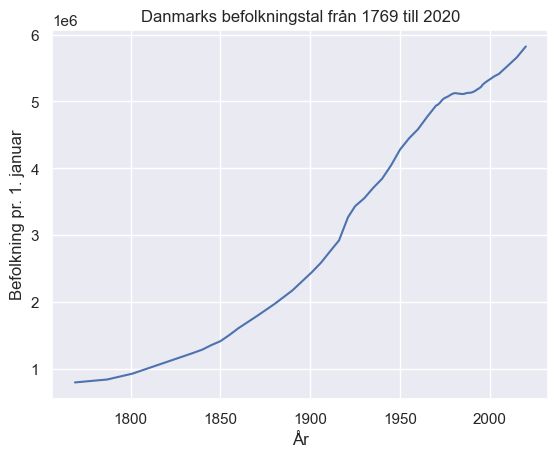

In [108]:
#plot dfd_new
sns.lineplot(data=dfd_new, x=dfd_new["År"], y=dfd_new["Befolkning pr. 1. januar"]).set(title="Danmarks befolkningstal från 1769 till 2020")


---
## 3. Norwegian demographic data (*)

Go to Swedish-language wikipedia page [Norges demografi](https://sv.wikipedia.org/wiki/Norges_demografi). 

&nbsp; a) Read in the table under "Befolkningsstatistik sedan 1900" into a DataFrame

&nbsp; b) You see some missing data in column "Total fertilitet". Go to the [English page](https://en.wikipedia.org/wiki/Demographics_of_Norway) and read in the data from "Vital statistics since 1900".  

&nbsp; c) Pick out the fertility column from b) dataset, merge it into a) dataset and clean the data so that you only have columns "År", "Folkmängd", "Fertilitet". 


---
## 4. Merge Sweden-Norway (*)

Create a population graph and a fertility graph showing Sweden and Norway.

<details>

<summary>Answer</summary>

![Fertilitet Norge och Sverige](../assets/fertilitet_sv_no.png)

![Folkmängd Norge och Sverige](../assets/folkmangd_sverige_norge.png)

</details>